#**FoodShock AI: A Machine Learning Prototype for Market-Level Food Price Shock Risk Detection in Bangladesh**

This project develops a machine learning prototype to identify and estimate the risk of unusually high food prices across different markets in Bangladesh. The system focuses on detecting market level price shocks and comparing risk levels across markets.

**Project Objective**

The main objective of this project is to explore whether machine learning can identify patterns associated with food price shocks and provide an early warning of potential market-level price risks.

**Research Questions**

1.Can machine learning identify unusually high food prices across different markets?

2.Which markets show a higher risk of experiencing a price shock?

3.Can market and time related information be used to build an early warning prototype?

**Initial Variables**

->Food Price

->Month

->Market



**Importing Libraries**

The required Python libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")


All libraries imported successfully!


In [92]:
from google.colab import files

uploaded = files.upload()

Saving Global WFP Food Prices.csv to Global WFP Food Prices (2).csv


**Data Loading and Initial Exploration**
 The Global WFP Food Prices dataset is loaded into Python using Pandas. The dataset is then examined to understand its size, variables, structure, and data quality.

In [ ]:
import pandas as pd

df = pd.read_csv("Global WFP Food Prices.csv")

df.head()

,country_code,date,county,subcounty,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,price_flag,price_type,currency,local_price,price_usd
0,AFG,2026-05-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Bread,55,KG,actual,Retail,AFN,77.0,1.20
1,AFG,2026-05-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (high quality),247,KG,actual,Retail,AFN,131.0,2.05
2,AFG,2026-05-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (low quality),145,KG,actual,Retail,AFN,66.0,1.03
3,AFG,2026-05-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat,84,KG,actual,Retail,AFN,27.0,0.42
4,AFG,2026-05-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat flour (high quality),178,KG,actual,Retail,AFN,33.0,0.52


In [ ]:
print(df.shape)
print(df.columns)

(207414, 17)
Index(['country_code', 'date', 'county', 'subcounty', 'market', 'market_id',
       'latitude', 'longitude', 'category', 'commodity', 'commodity_id',
       'unit', 'price_flag', 'price_type', 'currency', 'local_price',
       'price_usd'],
      dtype='object')


**Bangladesh Data Selection**

The dataset contains information from multiple countries. Therefore, only observations with the country code BGD are selected for the Bangladesh specific analysis.

In [90]:
# Check whether Bangladesh is in the dataset

countries = df['country_code'].unique()

print("BGD" in countries)

# Search for countries containing 'Bang'
print(df[df['country_code'].str.contains('BGd', case=False, na=False)]['country_code'].unique())

True
['BGD']


In [ ]:
print(df['country_code'].unique())

['AFG' 'ARM' 'BDI' 'BEN' 'BFA' 'BGD' 'BOL' 'CAF' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'DJI' 'DZA' 'ECU' 'EGY' 'ETH' 'GIN' 'GMB' 'GNB' 'GTM' 'IDN' 'IND'
 'IRN' 'IRQ' 'JOR' 'KEN' 'KGZ' 'KHM' 'LAO' 'LBN' 'LBR' 'LBY' 'LSO' 'MDA'
 'MDG' 'MLI' 'MMR' 'MOZ' 'MRT' 'MWI' 'NAM' 'NER' 'NGA' 'NIC' 'NPL' 'PAK'
 'PHL' 'PSE' 'RWA' 'SDN' 'SEN' 'SLE' 'SLV' 'SOM' 'SSD' 'SWZ' 'SYR' 'TCD'
 'TGO' 'TJK' 'TLS' 'TUR' 'TZA' 'UGA' 'UKR' 'YEM' 'ZMB' 'ZWE']


In [ ]:
print("Total countries:", df['country_code'].nunique())

print("\nSample countries:")
print(df['country_code'].value_counts().head(20))

Total countries: 70

Sample countries:
country_code
PHL    15517
SYR    15000
BEN    12909
MWI    11697
GMB    10193
IDN     8754
COD     6607
TCD     6559
BDI     6511
ETH     6176
BGD     5661
MLI     5610
UKR     4977
COL     4658
SSD     4212
AFG     3779
TJK     3646
SEN     3619
KGZ     3511
NGA     3474
Name: count, dtype: int64


In [ ]:
bangladesh_df = df[df['country_code'] == 'BGD']

print("Bangladesh data shape:", bangladesh_df.shape)

bangladesh_df.head()

Bangladesh data shape: (5661, 17)


,country_code,date,county,subcounty,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,price_flag,price_type,currency,local_price,price_usd
27938,BGD,2026-01-15,Barisal,Barguna,Barguna Sadar,4029,22.16,90.12,oil and fats,Oil (palm),62,L,actual,Retail,BDT,159.38,1.30
27939,BGD,2026-01-15,Barisal,Barguna,Barguna Sadar,4029,22.16,90.12,vegetables and fruits,"Onions (imported, China)",1108,KG,actual,Retail,BDT,62.23,0.51
27940,BGD,2026-01-15,Barisal,Barisal,Barisal Sadar,4082,22.71,90.36,oil and fats,Oil (palm),62,L,actual,Retail,BDT,164.50,1.34
27941,BGD,2026-01-15,Barisal,Bhola,Bhola Sadar,4030,22.69,90.64,vegetables and fruits,"Onions (imported, China)",1108,KG,actual,Retail,BDT,58.29,0.48
27942,BGD,2026-01-15,Barisal,Jhalokati,Jhalokati Sadar,4031,22.70,90.20,oil and fats,Oil (palm),62,L,actual,Retail,BDT,153.50,1.26


**Initial Commodity Exploration: Onion**



In [ ]:
# Searching for commodities containing the word 'onion'

onion_items = bangladesh_df[
    bangladesh_df['commodity'].str.contains('Onions', case=False, na=False)
]['commodity'].unique()

print(onion_items)

['Onions (imported, China)' 'Onions (imported, India)']


In [ ]:
# Filtering imported onions from India

onion_df = bangladesh_df[
    bangladesh_df['commodity'] == 'Onions (imported, India)'
].copy()

print("Onion data shape:", onion_df.shape)

onion_df.head()

Onion data shape: (20, 17)


,country_code,date,county,subcounty,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,price_flag,price_type,currency,local_price,price_usd
27998,BGD,2026-01-15,Chittagong,Chittagong,Bhashan Char,6424,22.33,91.16,vegetables and fruits,"Onions (imported, India)",1110,KG,actual,Retail,BDT,80.0,0.65
28044,BGD,2026-01-15,Chittagong,Cox'S Bazar,Cox`s Bazar Sadar,4054,21.47,91.98,vegetables and fruits,"Onions (imported, India)",1110,KG,actual,Retail,BDT,75.0,0.61
28102,BGD,2026-01-15,Chittagong,Cox'S Bazar,Teknaf Market,3159,20.87,92.30,vegetables and fruits,"Onions (imported, India)",1110,KG,actual,Retail,BDT,75.0,0.61
28159,BGD,2026-01-15,Chittagong,Cox'S Bazar,Ukhia Market,3162,21.24,92.14,vegetables and fruits,"Onions (imported, India)",1110,KG,actual,Retail,BDT,70.0,0.57
28353,BGD,2026-02-15,Chittagong,Chittagong,Bhashan Char,6424,22.33,91.16,vegetables and fruits,"Onions (imported, India)",1110,KG,actual,Retail,BDT,61.0,0.50


In [ ]:
print(onion_df[['date', 'market', 'commodity', 'local_price', 'unit']].head(10))

             date             market                 commodity  local_price  \
27998  2026-01-15       Bhashan Char  Onions (imported, India)         80.0   
28044  2026-01-15  Cox`s Bazar Sadar  Onions (imported, India)         75.0   
28102  2026-01-15      Teknaf Market  Onions (imported, India)         75.0   
28159  2026-01-15       Ukhia Market  Onions (imported, India)         70.0   
28353  2026-02-15       Bhashan Char  Onions (imported, India)         61.0   
28429  2026-02-15  Cox`s Bazar Sadar  Onions (imported, India)         60.0   
28488  2026-02-15      Teknaf Market  Onions (imported, India)         57.5   
28546  2026-02-15       Ukhia Market  Onions (imported, India)         55.0   
29099  2026-03-15       Bhashan Char  Onions (imported, India)         43.0   
29170  2026-03-15  Cox`s Bazar Sadar  Onions (imported, India)         55.0   

      unit  
27998   KG  
28044   KG  
28102   KG  
28159   KG  
28353   KG  
28429   KG  
28488   KG  
28546   KG  
29099   KG  


In [ ]:
# Convert date column to datetime format

onion_df['date'] = pd.to_datetime(onion_df['date'])

# Sort data by date

onion_df = onion_df.sort_values('date')

# Calculate average onion price for each date

monthly_price = onion_df.groupby('date')['local_price'].mean().reset_index()

# Rename the price column

monthly_price.rename(columns={'local_price': 'average_price'}, inplace=True)

monthly_price.head(10)

,date,average_price
0,2026-01-15,75.000
1,2026-02-15,58.375
2,2026-03-15,46.375
3,2026-04-15,39.575
4,2026-05-15,40.750


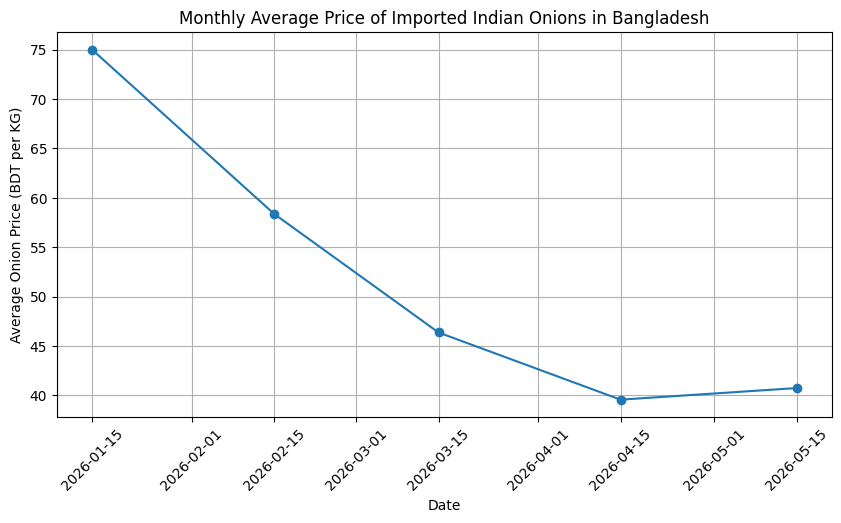

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_price['date'], monthly_price['average_price'], marker='o')

plt.xlabel('Date')
plt.ylabel('Average Onion Price (BDT per KG)')
plt.title('Monthly Average Price of Imported Indian Onions in Bangladesh')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Calculate monthly percentage price change

monthly_price['price_change_pct'] = monthly_price['average_price'].pct_change() * 100

monthly_price.head(10)

,date,average_price,price_change_pct
0,2026-01-15,75.000,NaN
1,2026-02-15,58.375,-22.166667
2,2026-03-15,46.375,-20.556745
3,2026-04-15,39.575,-14.663073
4,2026-05-15,40.750,2.969046


In [ ]:
# Define price shock

monthly_price['price_shock'] = (
    monthly_price['price_change_pct'] >= 10
).astype(int)

monthly_price.head(10)

,date,average_price,price_change_pct,price_shock
0,2026-01-15,75.000,NaN,0
1,2026-02-15,58.375,-22.166667,0
2,2026-03-15,46.375,-20.556745,0
3,2026-04-15,39.575,-14.663073,0
4,2026-05-15,40.750,2.969046,0


In [ ]:
print(monthly_price['price_shock'].value_counts())

price_shock
0    5
Name: count, dtype: int64


In [ ]:
print("Total observations:", len(monthly_price))

print("\nDate range:")
print(monthly_price['date'].min())
print(monthly_price['date'].max())

Total observations: 5

Date range:
2026-01-15 00:00:00
2026-05-15 00:00:00


In [ ]:
# Checking available date range and number of observations
# for both onion commodities

for item in [
    'Onions (imported, India)',
    'Onions (imported, China)'
]:
    temp = bangladesh_df[
        bangladesh_df['commodity'] == item
    ]

    print("\n", item)
    print("Observations:", len(temp))
    print("Date range:", temp['date'].min(), "to", temp['date'].max())


 Onions (imported, India)
Observations: 20
Date range: 2026-01-15 to 2026-05-15

 Onions (imported, China)
Observations: 55
Date range: 2026-01-15 to 2026-07-15


In [89]:
# How many observations are in bd's commodities

commodity_counts = (
    bangladesh_df.groupby('commodity')
    .agg(
        observations=('date', 'count'),
        start_date=('date', 'min'),
        end_date=('date', 'max')
    )
    .sort_values('observations', ascending=False)
)

commodity_counts.head(20)

,observations,start_date,end_date
commodity,,,
Chili (green),423,2026-01-15,2026-07-15
Papaya (green),402,2026-01-15,2026-07-15
"Oil (soybean, fortified)",401,2026-01-15,2026-07-15
Eggs (brown),401,2026-02-15,2026-07-15
Sugar,386,2026-01-15,2026-07-15
Oil (palm),382,2026-01-15,2026-07-15
Lentils (masur),345,2026-01-15,2026-07-15
Wheat flour,344,2026-01-15,2026-07-15
"Garlic (imported, China)",281,2026-01-15,2026-07-15


**Data Exploration and Commodity Selection**


We initially explored imported onion price data from India and China. However, the available data covered only a short time period, which was insufficient for reliable long term machine learning forecasting.

Therefore, after examining the available commodities, Green Chili was selected for further analysis because it contained the highest number of market level observations. The project focus was consequently refined toward market level food price shock detection rather than long term price forecasting.

In [ ]:
# Filtering Green Chili data

chili_df = bangladesh_df[
    bangladesh_df['commodity'] == 'Chili (green)'
].copy()

# Converting date to datetime
chili_df['date'] = pd.to_datetime(chili_df['date'])

# Sorting by date
chili_df = chili_df.sort_values('date')

print("Total observations:", len(chili_df))
print("Number of markets:", chili_df['market'].nunique())
print("Date range:", chili_df['date'].min(), "to", chili_df['date'].max())

chili_df[['date', 'market', 'local_price', 'unit']].head(10)

Total observations: 423
Number of markets: 92
Date range: 2026-01-15 00:00:00 to 2026-07-15 00:00:00


,date,market,local_price,unit
27990,2026-01-15,Bhashan Char,145.00,KG
28035,2026-01-15,Cox`s Bazar Sadar,120.00,KG
28094,2026-01-15,Teknaf Market,100.00,KG
28151,2026-01-15,Ukhia Market,80.00,KG
28716,2026-02-15,Jessore Sadar,117.94,KG
28728,2026-02-15,Jhenaidah Sadar,131.50,KG
28740,2026-02-15,Kushtia Sadar,107.35,KG
28750,2026-02-15,Magura Sadar,127.65,KG
28762,2026-02-15,Meherpur Sadar,116.91,KG
28774,2026-02-15,Narail Sadar,125.88,KG


**Exploratory Data Analysis: Price Distribution**


This section examines the distribution of green chili prices across different markets in Bangladesh.

In [ ]:
# Basic statistics of Green Chili prices

print(chili_df['local_price'].describe())

count    423.000000
mean     100.049882
std       35.990014
min       36.800000
25%       73.365000
50%       91.000000
75%      127.650000
max      213.200000
Name: local_price, dtype: float64


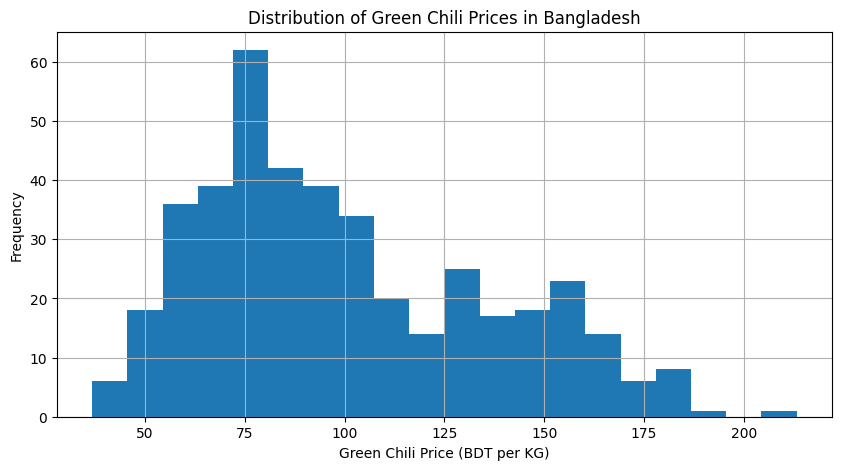

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(chili_df['local_price'], bins=20)

plt.xlabel('Green Chili Price (BDT per KG)')
plt.ylabel('Frequency')
plt.title('Distribution of Green Chili Prices in Bangladesh')

plt.grid(True)
plt.show()

**Price** **Shock**


A price shock is defined as an unusually high market price compared with the average price across markets on the same date. For this prototype, an observation is classified as a price shock when its price is at least 20% higher than the average price of the same commodity across all observed markets on that date.

In [ ]:
# Calculating the average Green Chili price across markets for each date

chili_df['date_average_price'] = (
    chili_df.groupby('date')['local_price'].transform('mean')
)

# Calculating how much each market's price differs from the date average

chili_df['price_difference_pct'] = (
    (chili_df['local_price'] - chili_df['date_average_price'])
    / chili_df['date_average_price']
) * 100

# Defining a price shock
# 1 = price is 20% or more above the average
# 0 = otherwise

chili_df['price_shock'] = (
    chili_df['price_difference_pct'] >= 20
).astype(int)

# Checking the result
chili_df[['date', 'market', 'local_price',
          'date_average_price',
          'price_difference_pct',
          'price_shock']].head(10)

,date,market,local_price,date_average_price,price_difference_pct,price_shock
27990,2026-01-15,Bhashan Char,145.00,111.250000,30.337079,1
28035,2026-01-15,Cox`s Bazar Sadar,120.00,111.250000,7.865169,0
28094,2026-01-15,Teknaf Market,100.00,111.250000,-10.112360,0
28151,2026-01-15,Ukhia Market,80.00,111.250000,-28.089888,0
28716,2026-02-15,Jessore Sadar,117.94,117.990588,-0.042875,0
28728,2026-02-15,Jhenaidah Sadar,131.50,117.990588,11.449567,0
28740,2026-02-15,Kushtia Sadar,107.35,117.990588,-9.018167,0
28750,2026-02-15,Magura Sadar,127.65,117.990588,8.186595,0
28762,2026-02-15,Meherpur Sadar,116.91,117.990588,-0.915826,0
28774,2026-02-15,Narail Sadar,125.88,117.990588,6.686475,0


In [ ]:
print(chili_df['price_shock'].value_counts())

print("\nPercentage distribution:")
print(chili_df['price_shock'].value_counts(normalize=True) * 100)

price_shock
0    367
1     56
Name: count, dtype: int64

Percentage distribution:
price_shock
0    86.761229
1    13.238771
Name: proportion, dtype: float64


**Feature Engineering**


To prepare the data for machine learning, two features are created from the available dataset: the month of observation and a numerical code representing each market. These features allow the model to examine patterns associated with time and market location.

In [ ]:
# Creating time-based features

chili_df['month'] = chili_df['date'].dt.month

# Encoding market names as numerical codes

chili_df['market_code'] = pd.factorize(chili_df['market'])[0]

# Creating a copy for machine learning

ml_df = chili_df.copy()

# Checking the new features

ml_df[['date', 'market', 'market_code', 'month',
       'local_price', 'price_shock']].head(10)

,date,market,market_code,month,local_price,price_shock
27990,2026-01-15,Bhashan Char,0,1,145.00,1
28035,2026-01-15,Cox`s Bazar Sadar,1,1,120.00,0
28094,2026-01-15,Teknaf Market,2,1,100.00,0
28151,2026-01-15,Ukhia Market,3,1,80.00,0
28716,2026-02-15,Jessore Sadar,4,2,117.94,0
28728,2026-02-15,Jhenaidah Sadar,5,2,131.50,0
28740,2026-02-15,Kushtia Sadar,6,2,107.35,0
28750,2026-02-15,Magura Sadar,7,2,127.65,0
28762,2026-02-15,Meherpur Sadar,8,2,116.91,0
28774,2026-02-15,Narail Sadar,9,2,125.88,0


Market names were converted into numerical codes for this prototype. These codes do not represent a natural numerical relationship between markets. Future versions should use one-hot encoding or geographical features such as latitude and longitude.

**Preparing Data for Machine Learning**


The predictor variables (features) are separated from the target variable. The target variable is price_shock, where 1 indicates an unusually high price and 0 indicates a normal price. The data is then divided into training and testing sets.

In [ ]:
# Selecting input features

X = ml_df[['month', 'market_code']]

# Selecting target variable

y = ml_df['price_shock']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
       month  market_code
27990      1            0
28035      1            1
28094      1            2
28151      1            3
28716      2            4

Target:
27990    1
28035    0
28094    0
28151    0
28716    0
Name: price_shock, dtype: int64


In [ ]:
# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 338
Testing observations: 85


**Logistic Regression Model**


A Logistic Regression model is used as the baseline machine learning classifier to predict whether a market observation is likely to be classified as a price shock.

In [ ]:
# Importing Logistic Regression model

from sklearn.linear_model import LogisticRegression

# Creating the model
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

# Training the model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Predicting on the testing data

y_pred_log = log_model.predict(X_test)

# Predicting probability of a price shock

y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred_log[:10])

print("\nFirst 10 shock probabilities:")
print(y_prob_log[:10])

First 10 predictions:
[1 0 0 0 1 0 0 0 1 1]

First 10 shock probabilities:
[0.68654542 0.38741992 0.38866905 0.34756505 0.52464965 0.31504005
 0.45267629 0.43400222 0.5528505  0.57340626]


**Model Evaluation**


The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-score, and a Confusion Matrix. Since price shocks are relatively rare, Recall and F1-score are particularly important for evaluating the model's ability to identify potential shocks.

In [ ]:
# Importing evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculating evaluation metrics

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_log, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

Accuracy: 0.6941176470588235
Precision: 0.2413793103448276
Recall: 0.6363636363636364
F1 Score: 0.35

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        74
           1       0.24      0.64      0.35        11

    accuracy                           0.69        85
   macro avg       0.58      0.67      0.57        85
weighted avg       0.84      0.69      0.74        85



In [ ]:
# Create Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[52 22]
 [ 4  7]]


**Random Forest Model**


A Random Forest classifier is used as a second model to capture potentially more complex relationships between market and time related features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Creating Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Training the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Making predictions

y_pred_rf = rf_model.predict(X_test)

# Probability of price shock
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred_rf[:10])

First 10 predictions:
[1 0 0 0 0 0 0 0 1 1]


**Random Forest Model Evaluation**


The Random Forest model is evaluated using the same performance metrics as Logistic Regression to compare their ability to detect market level food price shocks.

In [ ]:
# Evaluating Random Forest model

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Accuracy: 0.8588235294117647
Precision: 0.45454545454545453
Recall: 0.45454545454545453
F1 Score: 0.45454545454545453

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        74
           1       0.45      0.45      0.45        11

    accuracy                           0.86        85
   macro avg       0.69      0.69      0.69        85
weighted avg       0.86      0.86      0.86        85



In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[68  6]
 [ 6  5]]


In [ ]:
# Calculating and comparing model performance

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.694118,0.241379,0.636364,0.350000
1,Random Forest,0.858824,0.454545,0.454545,0.454545


**Model Selection**


Although Logistic Regression achieved a higher recall, Random Forest demonstrated superior overall accuracy, precision, and F1-score. Therefore, Random Forest was selected as the best performing model for this prototype. However, because this is an early warning application, future versions should further improve recall to reduce missed price shocks.

In [ ]:
# Selecting Random Forest as the final model

final_model = rf_model

print("Final Model: Random Forest")

Final Model: Random Forest


In [ ]:
market_mapping = (
    ml_df[['market', 'market_code']]
    .drop_duplicates()
    .sort_values('market_code')
    .reset_index(drop=True)
)

market_mapping

,market,market_code
0,Bhashan Char,0
1,Cox`s Bazar Sadar,1
2,Teknaf Market,2
3,Ukhia Market,3
4,Jessore Sadar,4
...,...,...
87,Bajitpur,87
88,Kaptai,88
89,Mirpur 1 no.,89
90,Kawran Bazar Dhaka,90


In [ ]:
# Creating a new observation for prediction

new_data = pd.DataFrame({
    'month': [7],
    'market_code': [90]
})

# Predicting price shock probability

shock_probability = final_model.predict_proba(new_data)[0][1]

# Converting probability into percentage

shock_percentage = shock_probability * 100

# Determining risk level

if shock_percentage >= 70:
    risk_level = "HIGH"
elif shock_percentage >= 40:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

print("Market: Kawran Bazar Dhaka")
print("Month: July")
print(f"Predicted Price Shock Risk: {shock_percentage:.2f}%")
print("Risk Level:", risk_level)

Market: Kawran Bazar Dhaka
Month: July
Predicted Price Shock Risk: 57.00%
Risk Level: MEDIUM


In [ ]:
# Creating July data for all markets

all_markets = market_mapping.copy()

prediction_data = pd.DataFrame({
    'month': [7] * len(all_markets),
    'market_code': all_markets['market_code']
})

# Predicting shock probabilities

all_markets['shock_probability'] = (
    final_model.predict_proba(prediction_data)[:, 1] * 100
)

# Creating risk levels

def get_risk_level(probability):
    if probability >= 70:
        return "HIGH"
    elif probability >= 40:
        return "MEDIUM"
    else:
        return "LOW"

all_markets['risk_level'] = all_markets['shock_probability'].apply(
    get_risk_level
)

# Sorting from highest to lowest risk

risk_results = all_markets.sort_values(
    'shock_probability',
    ascending=False
)

risk_results[['market', 'shock_probability', 'risk_level']].head(15)

,market,shock_probability,risk_level
64,Beanibazar,88.5,HIGH
65,Sunamgonj Sadar,75.5,HIGH
84,Singair,68.5,MEDIUM
26,Sylhet Sadar,68.0,MEDIUM
63,Golapganj,66.0,MEDIUM
89,Mirpur 1 no.,61.5,MEDIUM
47,Dhaka Sadar,59.5,MEDIUM
90,Kawran Bazar Dhaka,57.0,MEDIUM
85,Saturia,30.0,LOW
66,Banyachong,24.5,LOW


**Market-Level Price Shock Risk Ranking**


The model estimates different levels of price shock risk across markets. The following visualization ranks the top 15 markets according to their predicted probability of experiencing an abnormally high green chili price.

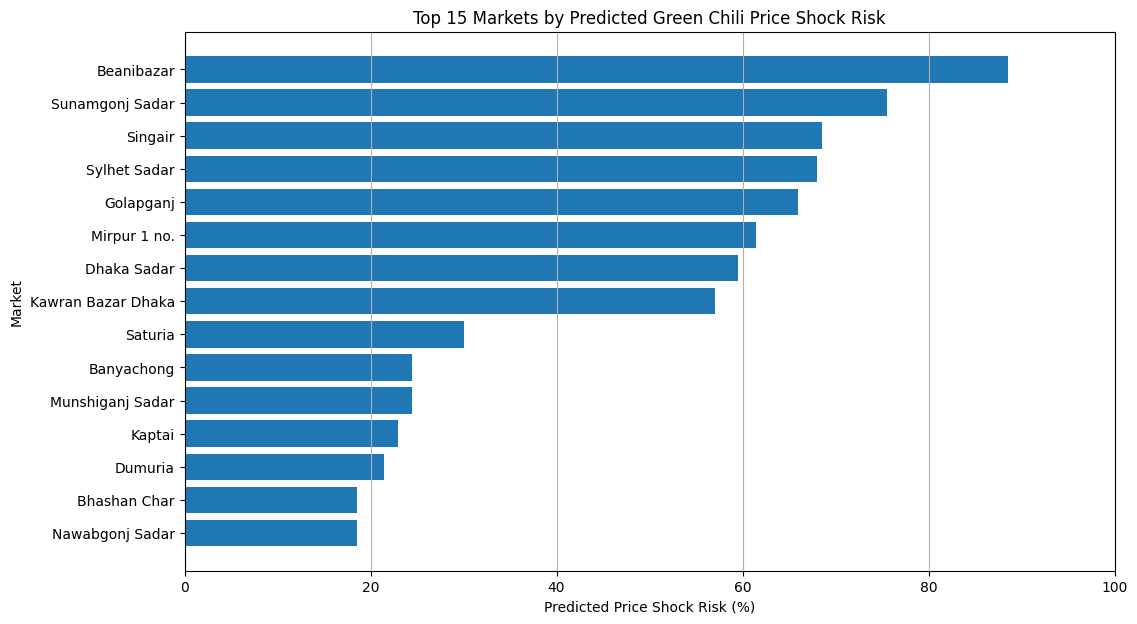

In [ ]:
# Selecting top 15 highest-risk markets

top_15_risk = risk_results.head(15)

# Creating the graph

plt.figure(figsize=(12, 7))

plt.barh(
    top_15_risk['market'],
    top_15_risk['shock_probability']
)

plt.xlabel('Predicted Price Shock Risk (%)')
plt.ylabel('Market')
plt.title('Top 15 Markets by Predicted Green Chili Price Shock Risk')

plt.xlim(0, 100)
plt.grid(axis='x')

plt.gca().invert_yaxis()

plt.show()

**Key Findings**


->The dataset contained 423 market-level observations for green chili prices across Bangladesh.

->A price shock was defined as a market price at least 20% above the average price across markets on the same date.

->56 observations (13.24%) were classified as potential price shocks.

->Two machine learning models were tested: Logistic Regression and Random Forest.

->Random Forest achieved the best overall performance with an accuracy of approximately 85.88% and an F1-score of approximately 45.45%.

->The model was used to estimate market level price shock risk for July.

->Beanibazar showed the highest predicted risk (88.5%), followed by Sunamganj Sadar (75.5%).

**Limitations**

This project is an early prototype and has several limitations. The available dataset covers only a short time period, from January to July 2026. The model uses only market and month related information and does not include important external factors such as inflation, rainfall, fuel prices, exchange rates, agricultural production, or import costs. Therefore, the predicted risk should be interpreted as a prototype-based market risk estimate rather than a definitive real world forecast.

**Conclusion**


This project demonstrates how machine learning can be used to identify and estimate market level food price shock risks. Using historical green chili price observations from Bangladesh, the prototype classified unusually high market prices and compared predicted risks across different markets. The results suggest that AI based systems could potentially support early warning and market monitoring. Future versions can be improved by incorporating longer historical datasets and broader economic, weather, and supply side indicators.